# Dataset Overview

This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

Attribute Information:

- age
- sex
- chest pain type (4 values)
- resting blood pressure
- serum cholestoral in mg/dl
- fasting blood sugar > 120 mg/dl
- resting electrocardiographic results (values 0,1,2)
- maximum heart rate achieved
- exercise induced angina
- oldpeak = ST depression induced by exercise relative to rest
- the slope of the peak exercise ST segment
- number of major vessels (0-3) colored by flourosopy
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect

The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

# Dataset Loading

## Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Libraries loaded

## Load Dataset

In [2]:
df= pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


14 attributes with 1 target column 'target' having binary classification

# Data Cleaning

## Handling Missing Values

In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

No null values present

## Handling Duplicate Values

In [5]:
df.duplicated().sum()

np.int64(723)

723 duplicate values are present

# Exploratory Data Analysis (EDA)

## Rows and Columns

In [6]:
df.shape

(1025, 14)

1025 rows and 14 attributes

## Columns info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


All the features are int64 type except 'oldpeak' which is float64 type

## Statistical Description

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Target feature distribution

In [9]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

Target variable distribution is manageable

## Target feature groupby analysis

In [10]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


Patients with target = 1 tend to have higher cp and thalach but lower exang and oldpeak, indicating these features strongly help differentiate the classes.

## Correlation Heatmap

<Axes: >

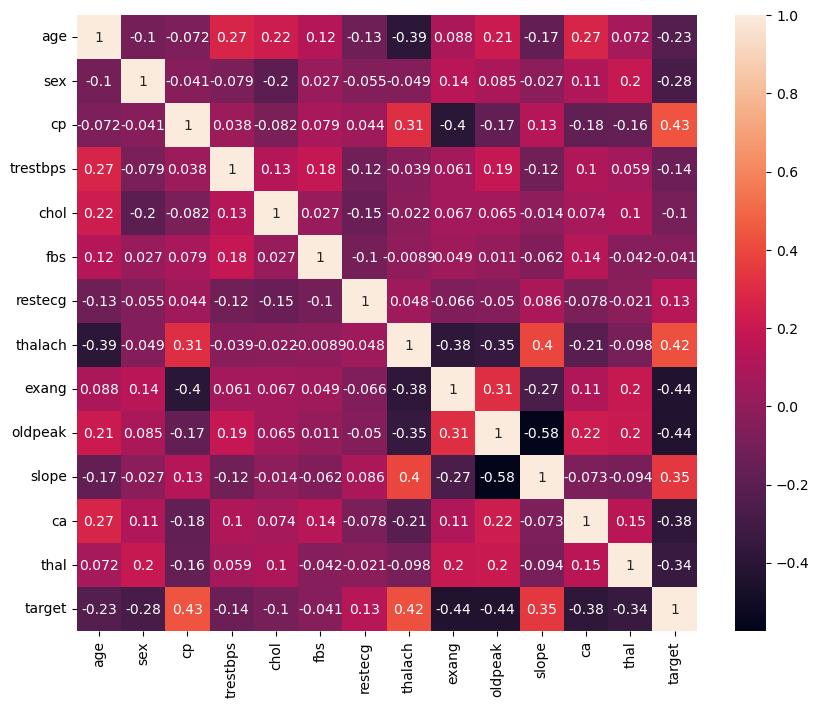

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)

The heatmap identifies chest pain (cp) and maximum heart rate (thalach) as the strongest positive predictors of heart disease, while exercise-induced angina (exang) and ST depression (oldpeak) serve as the most significant negative indicators.

## Distribution Plots

In [12]:
categorical = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
continuous = ['age','trestbps','chol','thalach','oldpeak']

### Continuous features vs target

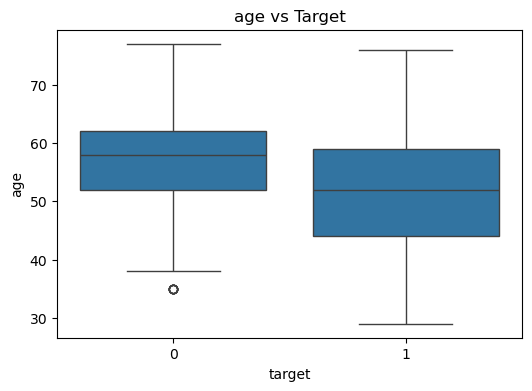

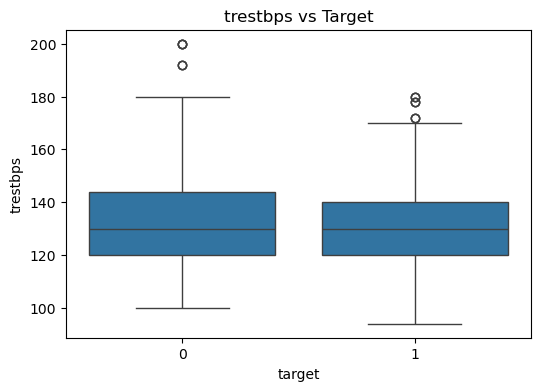

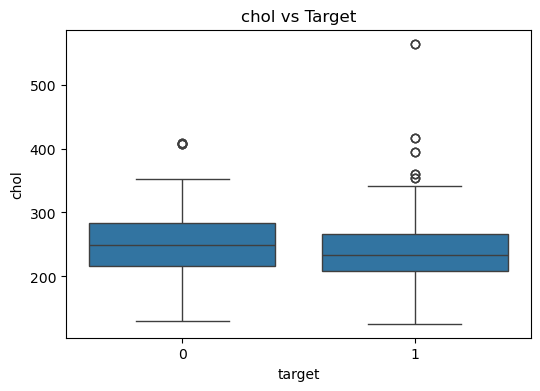

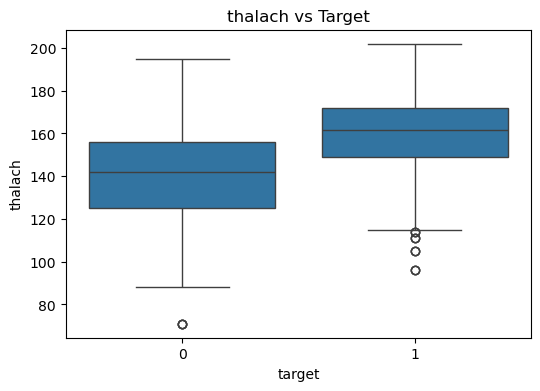

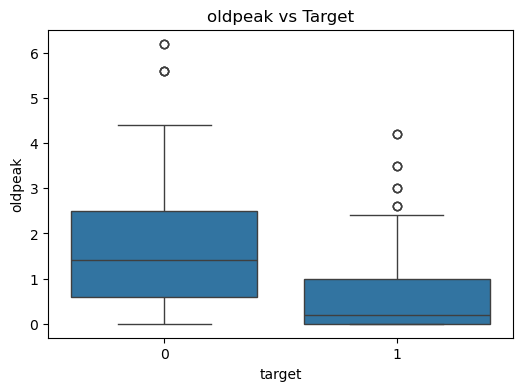

In [13]:
for col in continuous:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs Target')
    plt.show()

- High-Impact Indicators: Thalach (max heart rate) and Oldpeak (ST depression) are the most effective discriminators, showing distinct distribution shifts between groups that align with their high correlation scores.

- Low-Impact Factors: Trestbps (blood pressure) and Cholesterol show nearly identical medians across both groups, indicating they are poor standalone predictors despite being common clinical metrics.

### Categorical features vs target

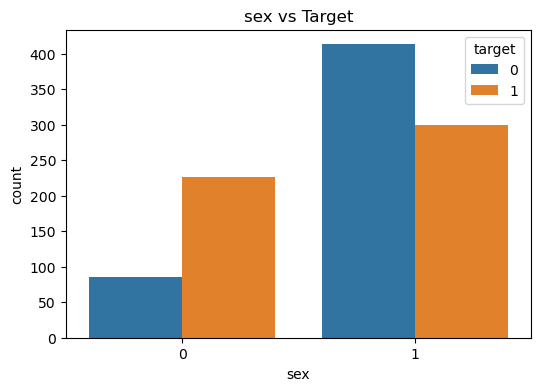

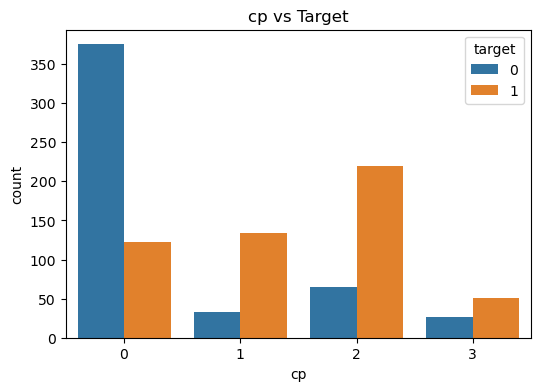

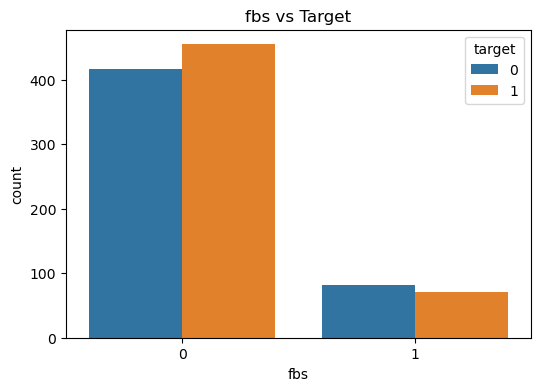

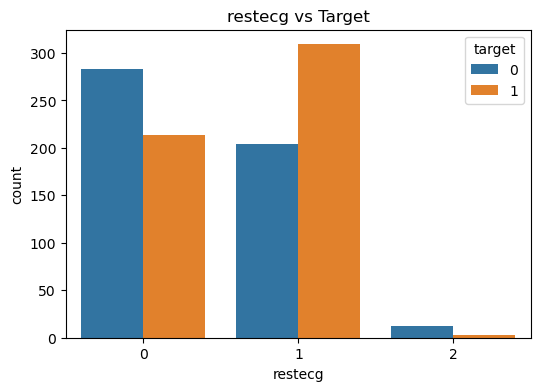

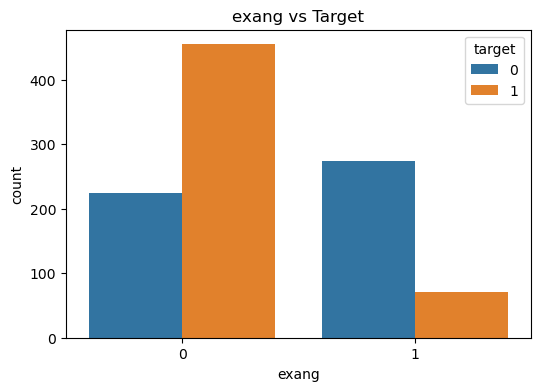

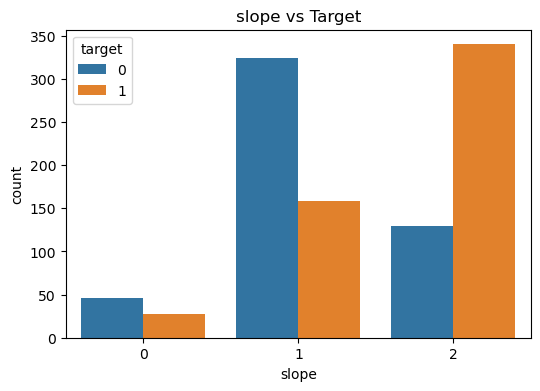

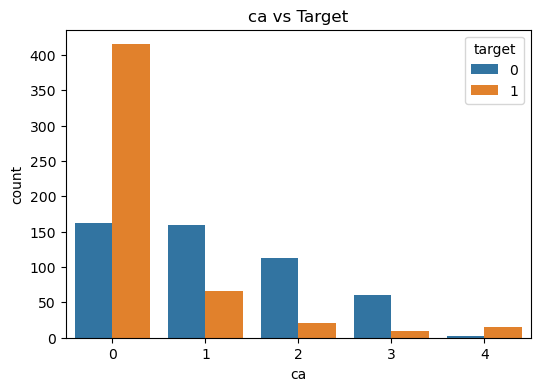

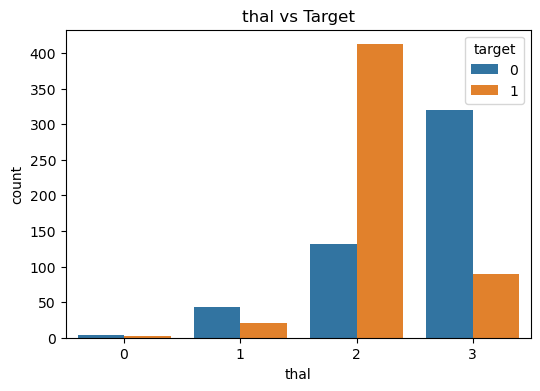

In [14]:
for col in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f'{col} vs Target')
    plt.show()

- Primary Predictors: Heart disease in this dataset is most strongly identified by lower age, higher maximum heart rates (thalach), specific chest pain types (1 & 2), and a lack of exercise-induced angina, while clinical markers like low ST depression (oldpeak) and zero major vessels (ca) serve as major red flags.

- Negligible Factors: Traditional risk metrics such as cholesterol, resting blood pressure, and fasting blood sugar show nearly identical distributions across both groups, making them unreliable standalone indicators for classification in this specific cohort.

## Insights

- Strongest Predictors: The most reliable indicators of heart disease are higher maximum heart rates (thalach), the presence of non-typical chest pain (cp types 1 & 2), and a lack of exercise-induced angina (exang).

- Clinical Red Flags: Significant diagnostic markers include lower ST depression (oldpeak), zero major vessels (ca) detected by fluoroscopy, and a specific thalassemia status (type 2).

- Weak/Counterintuitive Markers: Surprisingly, cholesterol, blood pressure, and fasting blood sugar show minimal difference between groups, while the heart disease group actually trends younger in this specific dataset.

# Train–Test Split

## Split features and target

In [15]:
X= df.drop(columns='target',axis=1)
y=df['target']

In [16]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [17]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

## Train–Test Split

In [18]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
X_train.shape, X_test.shape

((820, 13), (205, 13))

In [20]:
y_train.shape, y_test.shape

((820,), (205,))

## Standardization

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [22]:
X_train_std= scaler.fit_transform(X_train)
X_test_std= scaler.transform(X_test)

In [23]:
X_train_std

array([[-0.58584022,  0.65465367,  1.008275  , ...,  1.00526437,
         2.17169136, -0.54519316],
       [ 1.05147737, -1.52752523, -0.91672034, ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [-0.04006769, -1.52752523,  1.008275  , ...,  1.00526437,
        -0.7254674 , -0.54519316],
       ...,
       [-0.36753121,  0.65465367, -0.91672034, ...,  1.00526437,
        -0.7254674 ,  1.11057867],
       [-1.24076726,  0.65465367, -0.91672034, ...,  1.00526437,
        -0.7254674 ,  1.11057867],
       [-0.2583767 ,  0.65465367, -0.91672034, ...,  1.00526437,
         0.24025219, -0.54519316]])

In [24]:
X_test_std

array([[ 0.83316836, -1.52752523, -0.91672034, ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [-0.1492222 , -1.52752523,  1.008275  , ...,  1.00526437,
        -0.7254674 , -3.85673683],
       [ 0.06908682,  0.65465367, -0.91672034, ..., -0.64007851,
         0.24025219,  1.11057867],
       ...,
       [-1.13161275,  0.65465367,  1.008275  , ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [ 0.72401385,  0.65465367, -0.91672034, ...,  1.00526437,
         0.24025219,  1.11057867],
       [ 0.39655033,  0.65465367,  1.008275  , ..., -0.64007851,
         0.24025219,  1.11057867]])

# Model Training

## Import libraries

In [25]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

## Model layers

In [26]:
model = keras.Sequential([
    keras.layers.Input(shape=(13,)),
    keras.layers.Dense(12, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

## Compile model

In [27]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

## Train model

In [28]:
history=model.fit(X_train_std,y_train,validation_split=0.2,epochs=100,batch_size=16)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5244 - loss: 0.7167 - val_accuracy: 0.5915 - val_loss: 0.6844
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6341 - loss: 0.6538 - val_accuracy: 0.6402 - val_loss: 0.6424
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7104 - loss: 0.6030 - val_accuracy: 0.6707 - val_loss: 0.6065
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7698 - loss: 0.5493 - val_accuracy: 0.7317 - val_loss: 0.5706
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7805 - loss: 0.5194 - val_accuracy: 0.7622 - val_loss: 0.5387
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7866 - loss: 0.4757 - val_accuracy: 0.7683 - val_loss: 0.5129
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8110 - loss: 0.4496 - val_accuracy: 0.7744 - val_loss: 0.4941
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8216 - loss: 0.4174 - val_accuracy: 0.7866 - 

# Model Evaluation

In [29]:
loss, accuracy= model.evaluate(X_test_std,y_test)
print(accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8488 - loss: 0.3799
0.8487805128097534


In [30]:
y_pred = model.predict(X_test_std)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step 


In [31]:
y_pred = (y_pred > 0.5)

In [32]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[81 21]
 [10 93]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84       102
           1       0.82      0.90      0.86       103

    accuracy                           0.85       205
   macro avg       0.85      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205



Train Accuracy: 93%<br>
Test Accuracy: 85%<br>
Slight overfitting (improved by ML algorithms like logistic regression for smaller datasets like this)

# Plot Learning Curves

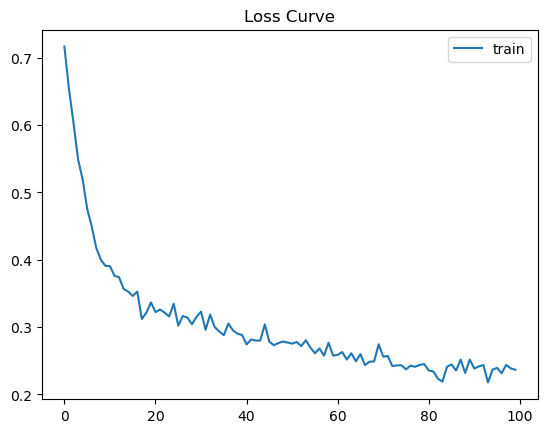

In [33]:
plt.plot(history.history['loss'])
plt.legend(['train'])
plt.title("Loss Curve")
plt.show()

# Save Model

In [34]:
import joblib
joblib.dump(model, "best_model.pkl")

['best_model.pkl']